<a href="https://colab.research.google.com/github/OBeatrice/AI-Customer-Feedback-Analyzer/blob/main/Predict_Podcast_Listening_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle



In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"olayinkaawofisayo","key":"7acd078f3d4bdf19241d4cb4f01850f4"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle competitions download -c playground-series-s5e4


In [5]:
import zipfile
import os

# List all downloaded zip files
for file in os.listdir():
    if file.endswith(".zip"):
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall()
        os.remove(file)  # Optionally remove the zip file after extraction


In [6]:
import pandas as pd

# Load the training data
train_df = pd.read_csv('train.csv')


In [7]:
# Display the first five rows
train_df.head()

# Get a concise summary of the DataFrame
print(train_df.info())

# Display summary statistics for numerical features
print(train_df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [8]:
# Display the first five rows
train_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


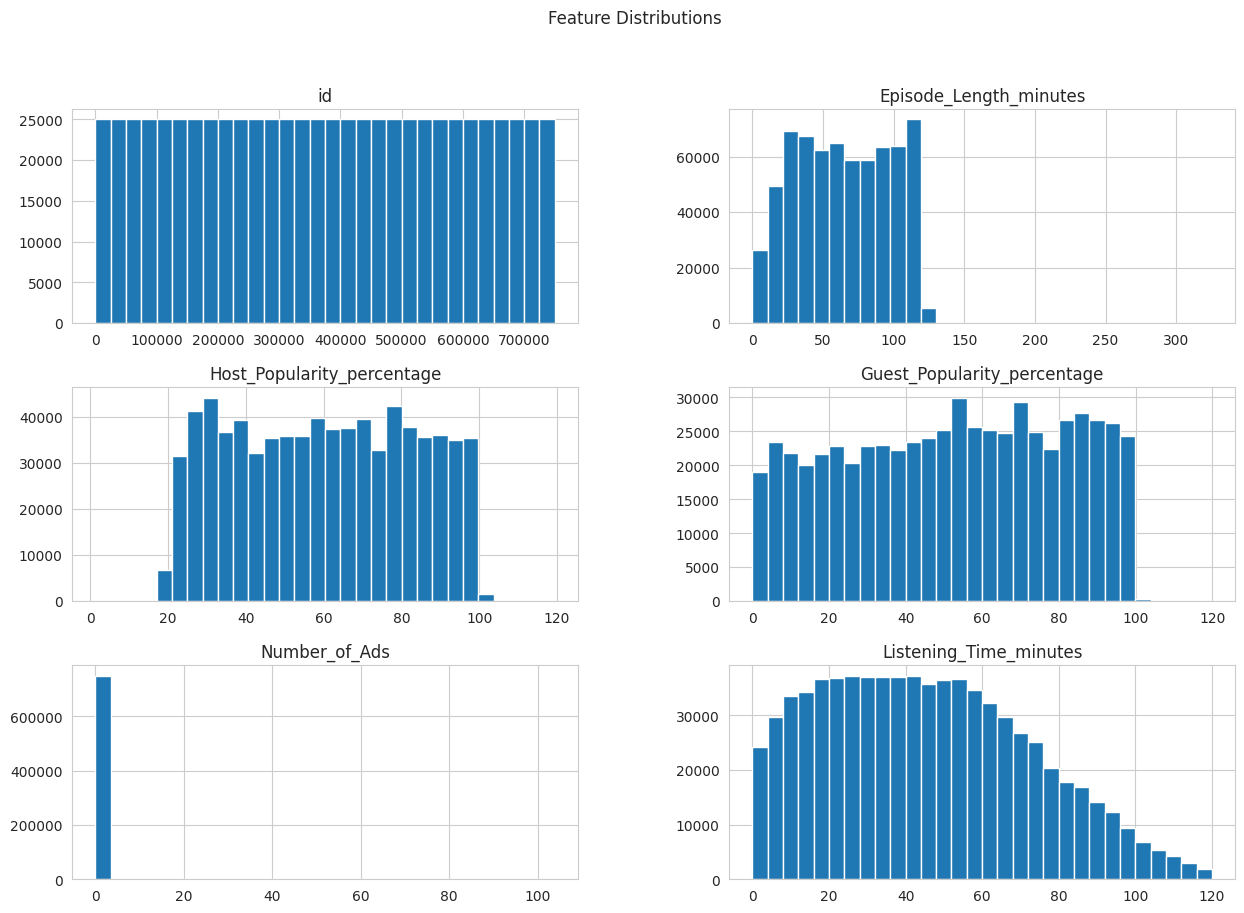

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Plot histograms for all numerical features
train_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.show()


In [10]:
# Select categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Display value counts for each categorical feature
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(train_df[col].value_counts())
    print('\n')


Value counts for Podcast_Name:
Podcast_Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928

In [11]:
# Select categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Display value counts for each categorical feature
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(train_df[col].value_counts())
    print('\n')


Value counts for Podcast_Name:
Podcast_Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928

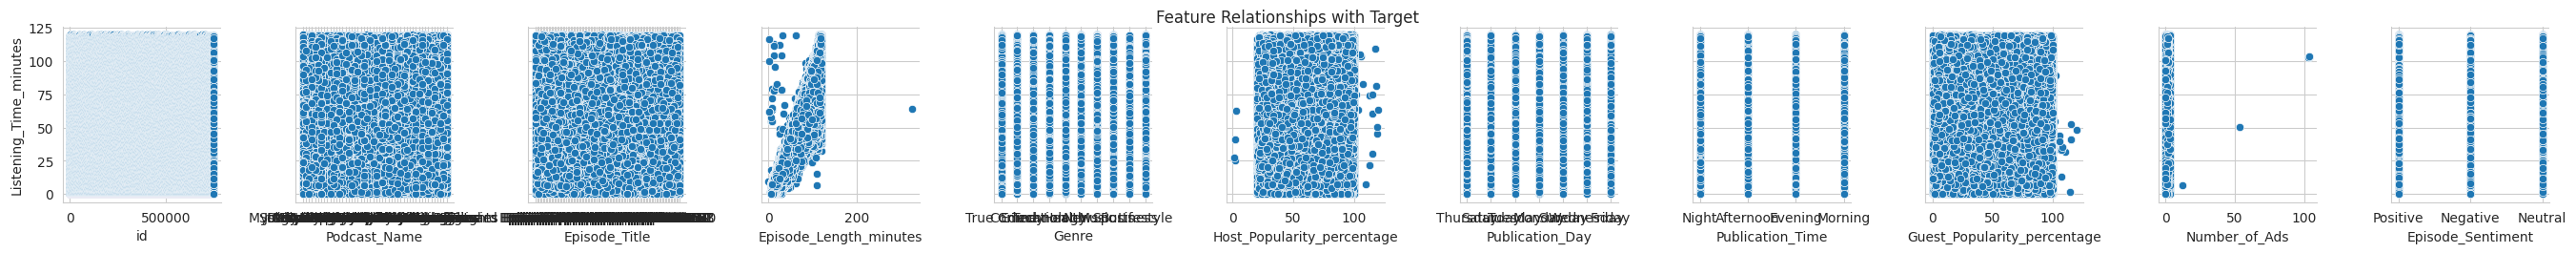

In [12]:
# Visualize pairwise relationships
sns.pairplot(train_df, y_vars=['Listening_Time_minutes'], x_vars=train_df.columns.drop('Listening_Time_minutes'))
plt.suptitle('Feature Relationships with Target', y=1.02)
plt.show()


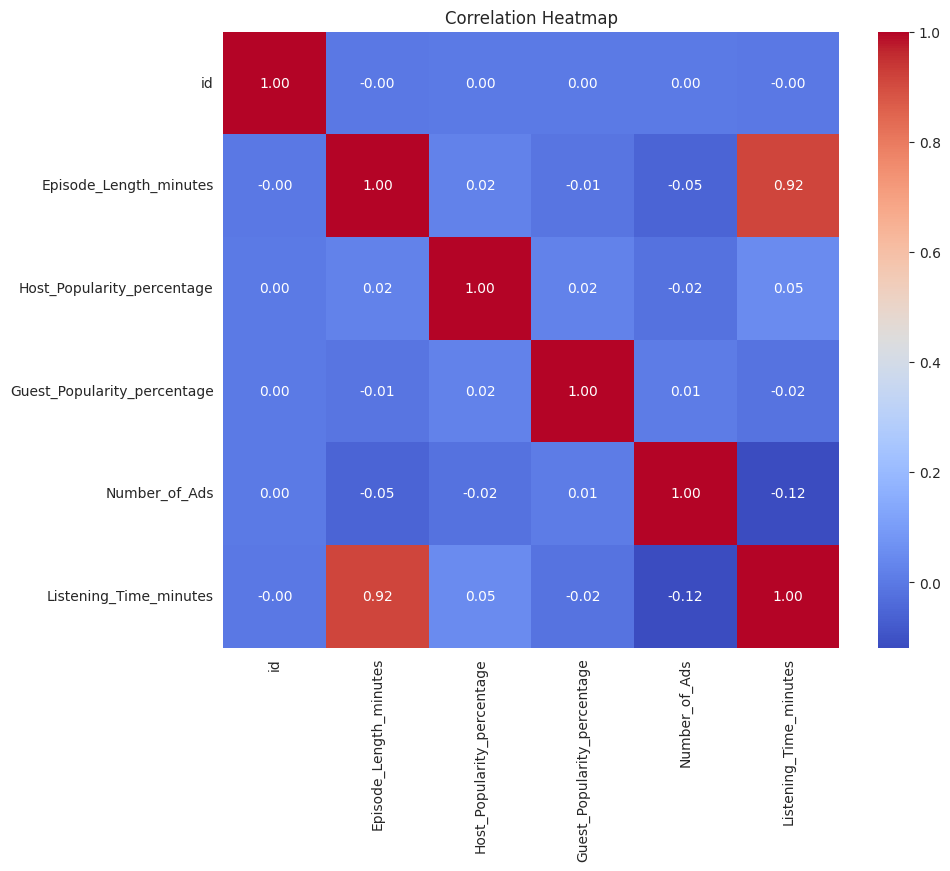

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix for numeric columns only
corr = train_df.corr(numeric_only=True)

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()


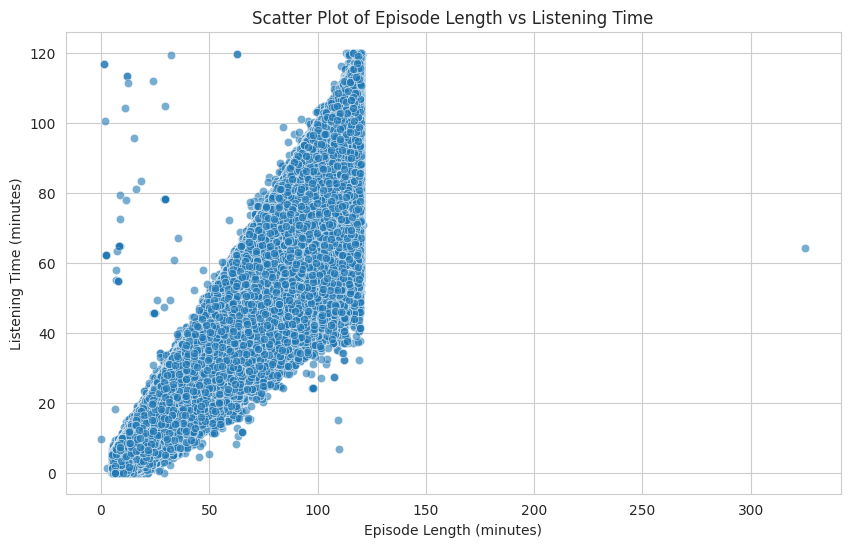

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Episode_Length_minutes',
    y='Listening_Time_minutes',
    data=train_df,
    alpha=0.6
)

plt.title('Scatter Plot of Episode Length vs Listening Time')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Listening Time (minutes)')
plt.grid(True)
plt.show()


<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

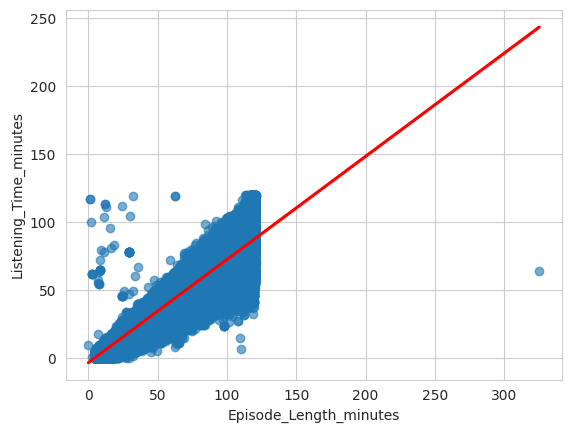

In [15]:
sns.regplot(
    x='Episode_Length_minutes',
    y='Listening_Time_minutes',
    data=train_df,
    scatter_kws={'alpha':0.6},
    line_kws={"color":"red"}
)


In [16]:
# Find episodes with very long Episode_Length_minutes
outliers_episode_length = train_df[train_df['Episode_Length_minutes'] > 150]

# Find episodes where Listening Time is abnormally high (above 120 minutes)
outliers_listening_time = train_df[train_df['Listening_Time_minutes'] > 120]

print("Outliers in Episode Length:")
print(outliers_episode_length)

print("\nOutliers in Listening Time:")
print(outliers_listening_time)


Outliers in Episode Length:
            id   Podcast_Name Episode_Title  Episode_Length_minutes  \
101637  101637  Home & Living    Episode 16                  325.24   

            Genre  Host_Popularity_percentage Publication_Day  \
101637  Lifestyle                       50.69         Tuesday   

       Publication_Time  Guest_Popularity_percentage  Number_of_Ads  \
101637        Afternoon                        15.01            0.0   

       Episode_Sentiment  Listening_Time_minutes  
101637          Positive                64.31981  

Outliers in Listening Time:
Empty DataFrame
Columns: [id, Podcast_Name, Episode_Title, Episode_Length_minutes, Genre, Host_Popularity_percentage, Publication_Day, Publication_Time, Guest_Popularity_percentage, Number_of_Ads, Episode_Sentiment, Listening_Time_minutes]
Index: []


In [17]:
# Remove the outlier with Episode_Length_minutes greater than 150 minutes
train_df = train_df[train_df['Episode_Length_minutes'] <= 150]

# Confirm it is removed
print("New shape of dataset:", train_df.shape)


New shape of dataset: (662906, 12)


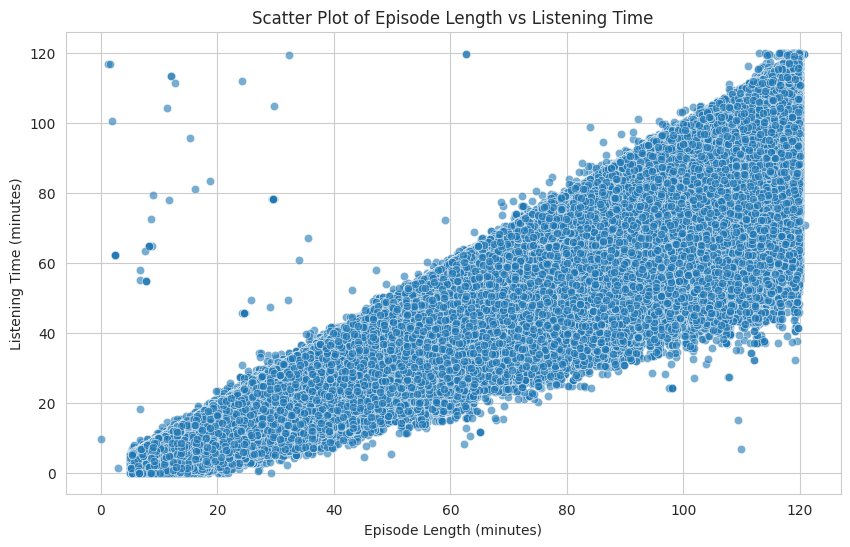

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Episode_Length_minutes',
    y='Listening_Time_minutes',
    data=train_df,
    alpha=0.6
)

plt.title('Scatter Plot of Episode Length vs Listening Time')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Listening Time (minutes)')
plt.grid(True)
plt.show()


<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

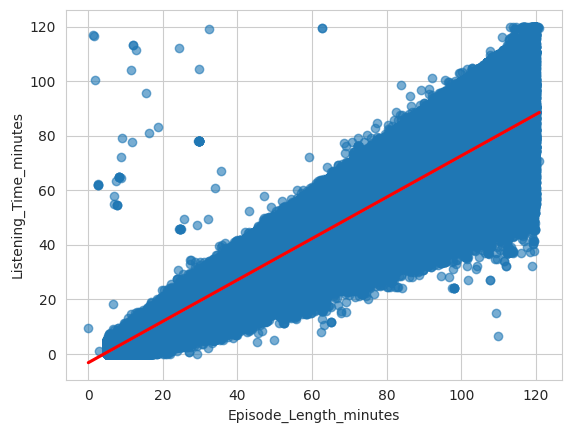

In [19]:
sns.regplot(
    x='Episode_Length_minutes',
    y='Listening_Time_minutes',
    data=train_df,
    scatter_kws={'alpha':0.6},
    line_kws={"color":"red"}
)



In [20]:
# Create Listening Efficiency
train_df['Listening_Efficiency'] = train_df['Listening_Time_minutes'] / train_df['Episode_Length_minutes']

# Display the first few rows to confirm
print(train_df[['Episode_Length_minutes', 'Listening_Time_minutes', 'Listening_Efficiency']].head())


   Episode_Length_minutes  Listening_Time_minutes  Listening_Efficiency
1                  119.80                88.01241              0.734661
2                   73.90                44.92531              0.607920
3                   67.17                46.27824              0.688972
4                  110.51                75.61031              0.684194
5                   26.54                22.77047              0.857968


In [21]:
# Find where Listening Efficiency is greater than 1
invalid_efficiency = train_df[train_df['Listening_Efficiency'] > 1]



# Also, how many such cases?
print("\nNumber of invalid efficiency cases:", invalid_efficiency.shape[0])



Number of invalid efficiency cases: 2568


In [22]:
# Display them
invalid_efficiency

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Listening_Efficiency
113,113,Current Affairs,Episode 44,17.94000,News,96.55,Saturday,Morning,13.40,1.0,Neutral,17.94199,1.000111
407,407,Sound Waves,Episode 56,11.26000,Music,44.26,Wednesday,Night,66.04,0.0,Positive,11.26579,1.000514
864,864,Life Lessons,Episode 29,28.92000,Lifestyle,49.84,Wednesday,Morning,19.85,2.0,Neutral,28.92051,1.000018
948,948,Educational Nuggets,Episode 59,96.10732,Education,85.95,Tuesday,Evening,90.83,2.0,Neutral,96.10741,1.000001
1316,1316,Market Masters,Episode 71,64.08000,Business,30.51,Sunday,Night,28.21,0.0,Positive,68.63865,1.071140
...,...,...,...,...,...,...,...,...,...,...,...,...,...
749074,749074,Gadget Geek,Episode 90,56.05000,Technology,54.09,Monday,Morning,68.02,0.0,Positive,60.11545,1.072533
749554,749554,Educational Nuggets,Episode 37,43.08000,Education,38.64,Wednesday,Afternoon,58.67,0.0,Negative,44.56000,1.034355
749622,749622,Lifestyle Lounge,Episode 8,52.69000,Lifestyle,90.80,Thursday,Evening,NaN,2.0,Positive,52.69952,1.000181
749649,749649,News Roundup,Episode 23,45.39000,News,96.09,Saturday,Morning,NaN,1.0,Neutral,46.61337,1.026952


In [23]:
# Display them
invalid_efficiency.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,Listening_Efficiency
count,2568.000000,2568.000000,2568.000000,2081.000000,2568.000000,2568.000000,2568.000000
mean,377709.529206,49.068815,65.423602,50.821946,1.038941,50.741287,inf
std,218733.213776,34.065915,24.008821,28.891965,1.004490,34.236991,NaN
min,113.000000,0.000000,20.000000,0.010000,0.000000,5.039530,1.000000
25%,184902.000000,16.580000,43.980000,26.690000,0.000000,17.885508,1.000068
50%,384821.000000,44.900000,69.760000,51.780000,1.000000,48.112810,1.000633
75%,567215.500000,74.670000,86.580000,75.100000,2.000000,76.206553,1.010013
max,749815.000000,119.920000,99.950000,99.980000,3.000000,119.970000,inf


In [24]:
# Find where Episode Length is exactly 0
zero_length_episodes = train_df[train_df['Episode_Length_minutes'] == 0]


# How many episodes have 0 minutes?
print("\nNumber of episodes with 0 minutes length:", zero_length_episodes.shape[0])




Number of episodes with 0 minutes length: 1


In [25]:
# Display them
zero_length_episodes

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Listening_Efficiency
150178,150178,Fashion Forward,Episode 16,0.0,Lifestyle,46.97,Friday,Afternoon,NaN,0.0,Negative,9.60684,inf


In [26]:
# Remove episodes where Episode_Length_minutes is 0
train_df = train_df[train_df['Episode_Length_minutes'] != 0]

print("Shape after removing zero-length episodes:", train_df.shape)


Shape after removing zero-length episodes: (662905, 13)


In [27]:
# Recalculate Listening Efficiency
train_df['Listening_Efficiency'] = train_df['Listening_Time_minutes'] / train_df['Episode_Length_minutes']

# Clip Listening Efficiency values to max 1
train_df['Listening_Efficiency'] = train_df['Listening_Efficiency'].clip(upper=1)

# Confirm it is now clean
print(train_df['Listening_Efficiency'].describe())


count    662905.000000
mean          0.680219
std           0.193336
min           0.000000
25%           0.566297
50%           0.698387
75%           0.822374
max           1.000000
Name: Listening_Efficiency, dtype: float64


<ipython-input-27-499a981efbab>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Listening_Efficiency'] = train_df['Listening_Time_minutes'] / train_df['Episode_Length_minutes']
<ipython-input-27-499a981efbab>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Listening_Efficiency'] = train_df['Listening_Efficiency'].clip(upper=1)


In [28]:
# How many episodes have Listening Efficiency = 0
zero_efficiency = train_df[train_df['Listening_Efficiency'] == 0]

print("Number of episodes with 0 listening efficiency:", zero_efficiency.shape[0])


Number of episodes with 0 listening efficiency: 7841


<ipython-input-29-528a684e026e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Efficiency_Zero'] = train_df['Listening_Efficiency'] == 0


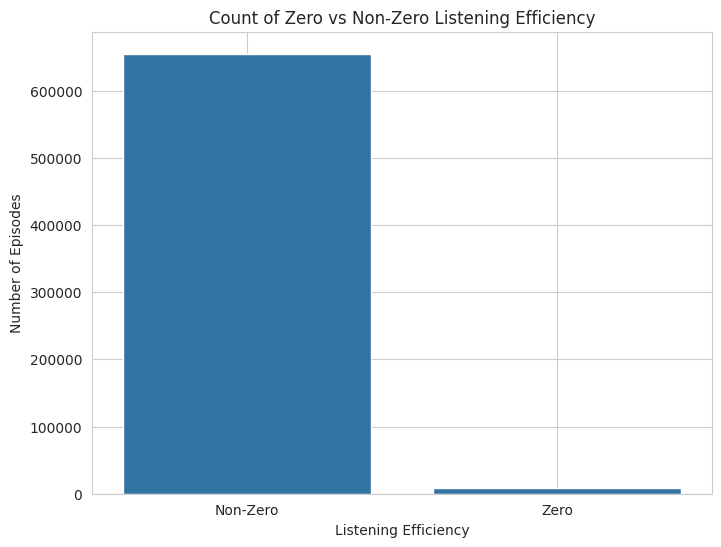

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column to classify
train_df['Efficiency_Zero'] = train_df['Listening_Efficiency'] == 0

# Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Efficiency_Zero', data=train_df)
plt.title('Count of Zero vs Non-Zero Listening Efficiency')
plt.xticks([0,1], ['Non-Zero', 'Zero'])
plt.ylabel('Number of Episodes')
plt.xlabel('Listening Efficiency')
plt.grid(True)
plt.show()


In [30]:
# Save the cleaned dataset to a CSV file
train_df.to_csv('train_cleaned.csv', index=False)


In [31]:
import os

# List files in current directory
print(os.listdir())


['.config', 'train.csv', 'test.csv', 'kaggle.json', 'sample_submission.csv', 'train_cleaned.csv', 'sample_data']


In [32]:
# Check correlation with target
correlation = train_df.corr(numeric_only=True)['Listening_Time_minutes'].sort_values(ascending=False)
print(correlation)


Listening_Time_minutes         1.000000
Episode_Length_minutes         0.916784
Listening_Efficiency           0.564912
Host_Popularity_percentage     0.048337
id                            -0.000618
Guest_Popularity_percentage   -0.013249
Number_of_Ads                 -0.119783
Efficiency_Zero               -0.183506
Name: Listening_Time_minutes, dtype: float64


In [36]:
import pandas as pd

# STEP 1: Define your numerical and categorical features
X_num = train_df[['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']]
X_cat = train_df[['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']]

# STEP 2: One-hot encode the categorical features
X_cat_encoded = pd.get_dummies(X_cat)

# STEP 3: Combine numeric and encoded categorical features
X_full = pd.concat([X_num, X_cat_encoded], axis=1)

# STEP 4: Fill any missing values
X_full = X_full.fillna(0)

# Confirm
print("X_full shape:", X_full.shape)


X_full shape: (662905, 28)


In [38]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

# Prepare X and y
X_num = train_df[['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']]
X_cat = train_df[['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']]

# One-hot encode categorical features
X_cat_encoded = pd.get_dummies(X_cat)

# Combine all features
X_full = pd.concat([X_num, X_cat_encoded], axis=1)

# Fill any missing values
X_full = X_full.fillna(0)

# Define target variable
y = train_df['Listening_Time_minutes']

# Now calculate Mutual Information
mi = mutual_info_regression(X_full, y)

# Convert to Series and sort
mi_series = pd.Series(mi, index=X_full.columns).sort_values(ascending=False)

# Display top features
print(mi_series.head(10))


Episode_Length_minutes         2.215597
Host_Popularity_percentage     0.743570
Guest_Popularity_percentage    0.628457
Number_of_Ads                  0.248328
Episode_Sentiment_Neutral      0.082239
Episode_Sentiment_Negative     0.075910
Episode_Sentiment_Positive     0.071445
Publication_Time_Night         0.065152
Publication_Time_Afternoon     0.063839
Publication_Time_Morning       0.061870
dtype: float64


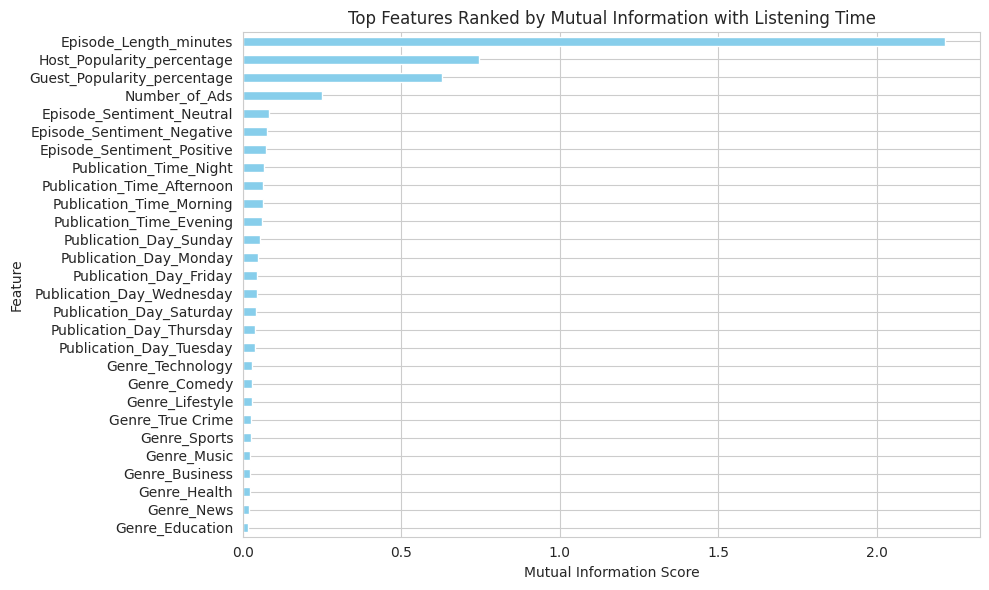

In [39]:
import matplotlib.pyplot as plt

# Sort if not already
mi_series_sorted = mi_series.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
mi_series_sorted.plot(kind='barh', color='skyblue')
plt.title('Top Features Ranked by Mutual Information with Listening Time')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(True)
plt.tight_layout()
plt.show()



In [40]:
# Select top important features
selected_features = [
    'Episode_Length_minutes',
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage',
    'Number_of_Ads',
    'Episode_Sentiment_Neutral',
    'Episode_Sentiment_Negative',
    'Episode_Sentiment_Positive',
    'Publication_Time_Morning',
    'Publication_Time_Afternoon',
    'Publication_Time_Evening',
    'Publication_Time_Night',
    'Publication_Day_Sunday',
    'Publication_Day_Monday',
    'Publication_Day_Tuesday',
    'Publication_Day_Wednesday',
    'Publication_Day_Thursday',
    'Publication_Day_Friday',
    'Publication_Day_Saturday'
]

# Define X (features) and y (target)
X = X_full[selected_features]
y = train_df['Listening_Time_minutes']

# Confirm shape
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (662905, 18)
Target shape: (662905,)


In [41]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm shapes
print("Training features shape:", X_train.shape)
print("Validation features shape:", X_valid.shape)
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_valid.shape)


Training features shape: (530324, 18)
Validation features shape: (132581, 18)
Training target shape: (530324,)
Validation target shape: (132581,)


In [42]:
# Fill missing values in X_train and X_valid
X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on validation set
y_pred = lr_model.predict(X_valid)

# Evaluate the model
mae = mean_absolute_error(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred)

print("Linear Regression Performance:")
print(f"MAE  (Mean Absolute Error)  : {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R²   (R-squared)             : {r2:.2f}")


Linear Regression Performance:
MAE  (Mean Absolute Error)  : 8.25
RMSE (Root Mean Squared Error): 10.67
R²   (R-squared)             : 0.85


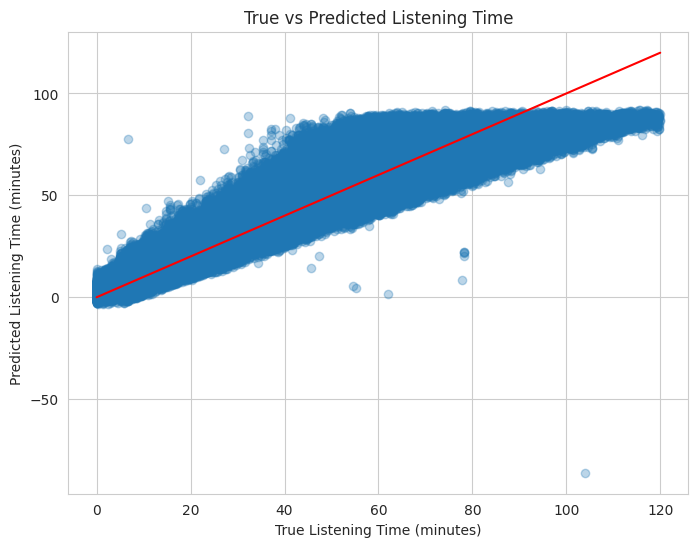

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred, alpha=0.3)
plt.xlabel('True Listening Time (minutes)')
plt.ylabel('Predicted Listening Time (minutes)')
plt.title('True vs Predicted Listening Time')
plt.plot([0, max(y_valid)], [0, max(y_valid)], color='red')  # Diagonal perfect line
plt.grid(True)
plt.show()


In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,  # number of trees
    random_state=42,
    n_jobs=-1          # use all CPUs for speed
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_rf = rf_model.predict(X_valid)

# Evaluate the model
mae_rf = mean_absolute_error(y_valid, y_pred_rf)
mse_rf = mean_squared_error(y_valid, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_valid, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE  (Mean Absolute Error)  : {mae_rf:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.2f}")
print(f"R²   (R-squared)             : {r2_rf:.2f}")


Random Forest Performance:
MAE  (Mean Absolute Error)  : 7.52
RMSE (Root Mean Squared Error): 10.06
R²   (R-squared)             : 0.86


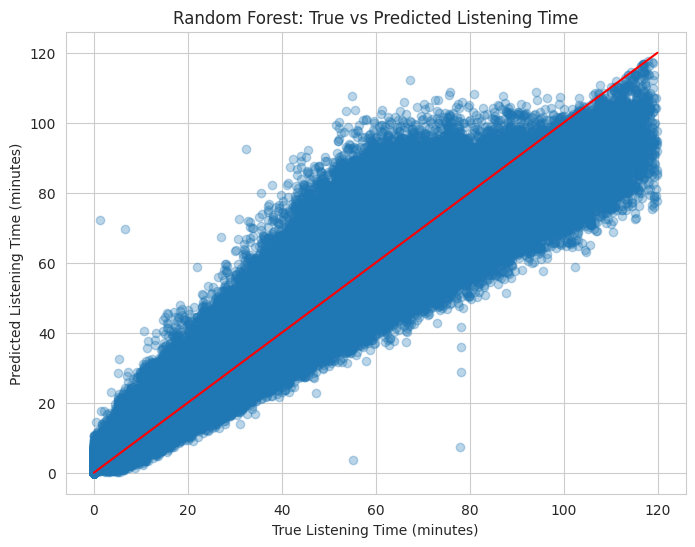

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred_rf, alpha=0.3)
plt.xlabel('True Listening Time (minutes)')
plt.ylabel('Predicted Listening Time (minutes)')
plt.title('Random Forest: True vs Predicted Listening Time')
plt.plot([0, max(y_valid)], [0, max(y_valid)], color='red')  # Perfect line
plt.grid(True)
plt.show()


In [47]:
!pip install xgboost


In [48]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [49]:
# Initialize the model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Fit to training data
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [50]:
# Predict on validation set
y_pred_xgb = xgb_model.predict(X_valid)


In [51]:
# Evaluate
mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
mse_xgb = mean_squared_error(y_valid, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_valid, y_pred_xgb)

print("XGBoost Performance:")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.2f}")


XGBoost Performance:
MAE  : 7.99
RMSE : 10.37
R²   : 0.86


In [52]:
# Average predictions from both models
y_pred_blend = (y_pred_xgb + y_pred_rf) / 2

# Evaluate blended performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_blend = mean_absolute_error(y_valid, y_pred_blend)
rmse_blend = np.sqrt(mean_squared_error(y_valid, y_pred_blend))
r2_blend = r2_score(y_valid, y_pred_blend)

print("Blended Model Performance:")
print(f"MAE  : {mae_blend:.2f}")
print(f"RMSE : {rmse_blend:.2f}")
print(f"R²   : {r2_blend:.2f}")


Blended Model Performance:
MAE  : 7.69
RMSE : 10.07
R²   : 0.86


In [57]:
# Rebuild the test features just like the training data

# 1. Load your test data
test_df = pd.read_csv('test.csv')

# 2. Select numeric features
X_test_num = test_df[['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']]

# 3. One-hot encode categorical features
X_test_cat = test_df[['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']]
X_test_cat_encoded = pd.get_dummies(X_test_cat)

# 4. Combine numeric and categorical
X_test_full = pd.concat([X_test_num, X_test_cat_encoded], axis=1)

# 5. Fill any missing values
X_test_full = X_test_full.fillna(0)

# 6. Align the test columns with training columns
X_test_full = X_test_full.reindex(columns=X_train.columns, fill_value=0)

# Confirm shape
print("X_test_full shape:", X_test_full.shape)


X_test_full shape: (250000, 18)


In [59]:
# Predict on the test set using both models
test_preds_rf = rf_model.predict(X_test_full)
test_preds_xgb = xgb_model.predict(X_test_full)

# Blend predictions
test_preds_blend = (test_preds_rf + test_preds_xgb) / 2

# Clip negative predictions to 0
test_preds_blend = np.clip(test_preds_blend, 0, None)

# Build submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Listening_Time_minutes': test_preds_blend
})

# Save CSV
submission.to_csv('submission_blended.csv', index=False)

# Optional: Download
from google.colab import files
files.download('submission_blended.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>